In [ ]:
log_probs = F.log_softmax(response_logits / temperature, dim=-1)

| 组件                           | 含义                                          |
| ---------------------------- | ------------------------------------------- |
| `response_logits`            | 模型输出的原始分数，形状 `(bsz, seq_len, vocab_size)`   |
| `/ temperature`              | 温度缩放（Temperature Scaling）                   |
| `F.log_softmax(..., dim=-1)` | 在 vocab 维度上计算 log softmax                   |
| `log_probs`                  | 结果：log 概率分布，形状 `(bsz, seq_len, vocab_size)` |

# 分步详解
##  原始 Logits
- 这些原始分数可以是任意实数（正、负、大、小），不是概率。

In [ ]:
response_logits: (bsz, seq_len, vocab_size)

# 例如：
# batch_size = 2
# seq_len = 3 (response 长度)
# vocab_size = 5

response_logits[0, 0] = [2.0, 1.0, 0.5, 3.0, 1.5]  # 第一个样本，第一个位置
response_logits[0, 1] = [0.5, 2.5, 1.0, 0.0, 3.0]  # 第一个样本，第二个位置

## 温度缩放（Temperature Scaling）
- 作用：控制概率分布的"尖锐程度"

| Temperature    | 效果                              |
| -------------- | ------------------------------- |
| $T \to 0$      | 分布趋近于 one-hot（最确定的 token 概率接近1） |
| $T = 1$        | 标准 softmax，保持原始 logits 的相对关系    |
| $T \to \infty$ | 分布趋近于均匀（所有 token 概率相等）          |


In [ ]:
response_logits / temperature

### 数学原理：
softmax(z 

  
- <font color='red'>当 T  很小时，指数函数放大差异，分布更尖锐。</font>
- 当 T  很大时，指数函数压缩差异，分布更平缓。 

### <font color='red'> 可视化：</font>

In [ ]:
logits = [2.0, 1.0, 0.5, 3.0, 1.5]

T=0.5 (低温，尖锐):
  [2/0.5, 1/0.5, 0.5/0.5, 3/0.5, 1.5/0.5] = [4, 2, 1, 6, 3]
  softmax ≈ [0.02, 0.00, 0.00, 0.98, 0.00]
  → 几乎确定选择索引3

T=1.0 (标准):
  [2, 1, 0.5, 3, 1.5]
  softmax ≈ [0.12, 0.04, 0.03, 0.67, 0.14]
  → 索引3概率最高，但其他也有可能

T=2.0 (高温，平缓):
  [1, 0.5, 0.25, 1.5, 0.75]
  softmax ≈ [0.20, 0.12, 0.10, 0.35, 0.23]
  → 分布更均匀，探索性更强

## Log Softmax

In [ ]:
F.log_softmax(x, dim=-1)

##### 等价于：
- 但数值更稳定（防止下溢）。

In [ ]:
log_probs = torch.log(F.softmax(x, dim=-1))

##### 计算过程：

In [ ]:
输入: [z1, z2, z3, z4, z5] (经过温度缩放后的 logits)

Step 1: 减去最大值（数值稳定性）
  z_max = max(z1, z2, z3, z4, z5)
  z_shifted = [z1-z_max, z2-z_max, z3-z_max, z4-z_max, z5-z_max]

Step 2: 计算 exp
  exp_z = [e^(z1-z_max), e^(z2-z_max), ...]

Step 3: 归一化
  sum_exp = sum(exp_z)
  probs = [e^(z1-z_max)/sum_exp, ...]

Step 4: 取 log
  log_probs = [z1-z_max-log(sum_exp), z2-z_max-log(sum_exp), ...]

# 完整示例

In [1]:

import torch
import torch.nn.functional as F

print("=" * 60)
print("log_probs = F.log_softmax(response_logits / temperature, dim=-1)")
print("=" * 60)

# 设置参数
vocab_size = 5
response_logits = torch.tensor([
    [2.0, 1.0, 0.5, 3.0, 1.5],  # 位置 0
    [0.5, 2.5, 1.0, 0.0, 3.0],  # 位置 1
])

print(f"\n原始 logits (2个位置, vocab_size={vocab_size}):")
print(response_logits)

# 不同温度下的效果
for temperature in [0.5, 1.0, 2.0]:
    print(f"\n{'='*50}")
    print(f"Temperature = {temperature}")
    print(f"{'='*50}")
    
    # 温度缩放
    scaled_logits = response_logits / temperature
    print(f"\n温度缩放后的 logits:")
    print(scaled_logits)
    
    # log_softmax
    log_probs = F.log_softmax(scaled_logits, dim=-1)
    print(f"\nlog_probs (log_softmax 结果):")
    print(log_probs)
    
    # 转回概率
    probs = torch.exp(log_probs)
    print(f"\nprobs (exp 后):")
    print(probs)
    
    # 验证概率和为1
    print(f"\n概率和: {probs.sum(dim=-1)}")
    
    # 最可能的 token
    max_probs, max_indices = probs.max(dim=-1)
    print(f"\n最大概率: {max_probs}")
    print(f"最可能的 token 索引: {max_indices}")


log_probs = F.log_softmax(response_logits / temperature, dim=-1)

原始 logits (2个位置, vocab_size=5):
tensor([[2.0000, 1.0000, 0.5000, 3.0000, 1.5000],
        [0.5000, 2.5000, 1.0000, 0.0000, 3.0000]])

Temperature = 0.5

温度缩放后的 logits:
tensor([[4., 2., 1., 6., 3.],
        [1., 5., 2., 0., 6.]])

log_probs (log_softmax 结果):
tensor([[-2.1908, -4.1908, -5.1908, -0.1908, -3.1908],
        [-5.3332, -1.3332, -4.3332, -6.3332, -0.3332]])

probs (exp 后):
tensor([[0.1118, 0.0151, 0.0056, 0.8263, 0.0411],
        [0.0048, 0.2636, 0.0131, 0.0018, 0.7166]])

概率和: tensor([1.0000, 1.0000])

最大概率: tensor([0.8263, 0.7166])
最可能的 token 索引: tensor([3, 4])

Temperature = 1.0

温度缩放后的 logits:
tensor([[2.0000, 1.0000, 0.5000, 3.0000, 1.5000],
        [0.5000, 2.5000, 1.0000, 0.0000, 3.0000]])

log_probs (log_softmax 结果):
tensor([[-1.5925, -2.5925, -3.0925, -0.5925, -2.0925],
        [-3.1279, -1.1279, -2.6279, -3.6279, -0.6279]])

probs (exp 后):
tensor([[0.2034, 0.0748, 0.0454, 0.5530, 0.1234],
        [0.04

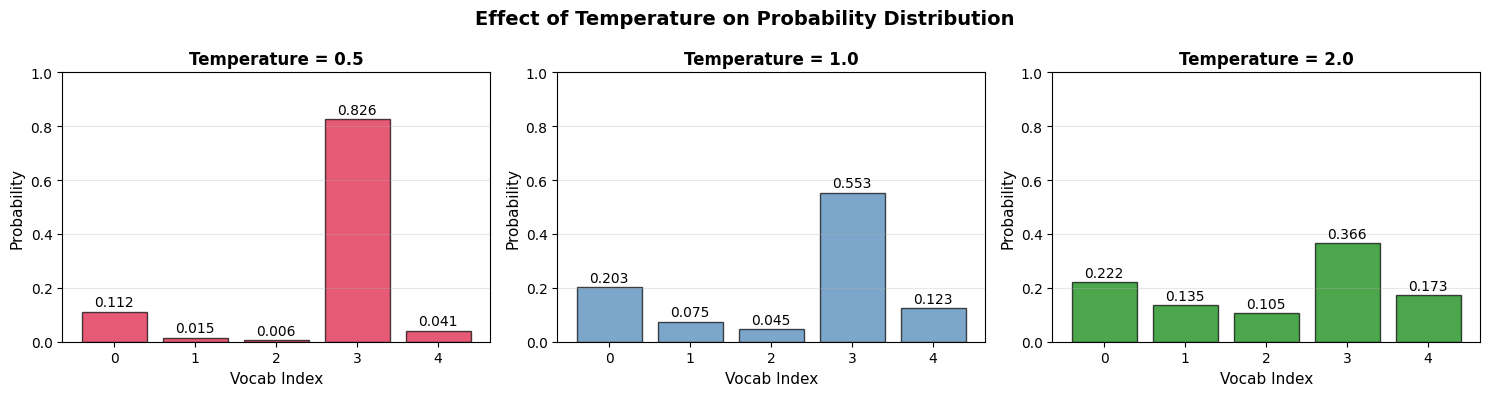


图表已保存


In [4]:
import torch
import torch.nn.functional as F
# 可视化温度对分布的影响
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

logits = torch.tensor([2.0, 1.0, 0.5, 3.0, 1.5])
temperatures = [0.5, 1.0, 2.0]
colors = ['crimson', 'steelblue', 'green']

for idx, (T, color) in enumerate(zip(temperatures, colors)):
    ax = axes[idx]
    
    # 计算概率
    scaled = logits / T
    log_probs = F.log_softmax(scaled, dim=-1)
    probs = torch.exp(log_probs).numpy()
    
    # 绘制
    bars = ax.bar(range(len(probs)), probs, color=color, edgecolor='black', alpha=0.7)
    
    # 标注数值
    for i, (bar, p) in enumerate(zip(bars, probs)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{p:.3f}', ha='center', fontsize=10)
    
    ax.set_xlabel('Vocab Index', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Temperature = {T}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(range(len(probs)))
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Effect of Temperature on Probability Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./temperature_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存")


In [ ]:

# 在 RL 训练中的完整流程
print("=" * 60)
print("在 RL 训练中的完整流程")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────────┐
│              log_probs 在 RL 训练中的使用                   │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  Step 1: 模型前向传播                                       │
│    └── output = actor_module(input_ids)                    │
│        └── logits: (bsz, seqlen, vocab_size)               │
│                                                             │
│  Step 2: 切片到 response 部分                               │
│    └── response_logits = logits[:, prompt_len-1:-1, :]     │
│        └── (bsz, response_len, vocab_size)                 │
│                                                             │
│  Step 3: 温度缩放 + log_softmax                             │
│    └── log_probs = F.log_softmax(response_logits / T, -1)│
│        └── (bsz, response_len, vocab_size)                 │
│        └── 每个位置是一个 vocab 上的 log 概率分布           │
│                                                             │
│  Step 4: 提取实际生成 token 的 log_prob                     │
│    └── token_log_probs = gather(log_probs, responses)      │
│        └── (bsz, response_len)                             │
│        └── 每个位置是实际生成 token 的 log_prob             │
│                                                             │
│  Step 5: 计算 PPO ratio                                     │
│    └── ratio = exp(token_log_probs - old_log_probs)       │
│        └── (bsz, response_len)                             │
│                                                             │
│  Step 6: 计算 PPO loss                                      │
│    └── pg_loss = f(ratio, advantages)                      │
│                                                             │
└─────────────────────────────────────────────────────────────┘
""")

# 完整模拟
bsz, response_len, vocab_size = 2, 3, 5

# 模拟 response_logits
response_logits = torch.randn(bsz, response_len, vocab_size)
print(f"response_logits 形状: {response_logits.shape}")
print(f"response_logits[0, 0]: {response_logits[0, 0]}")

# 温度
temperature = 1.0

# Step 3: log_softmax
log_probs = F.log_softmax(response_logits / temperature, dim=-1)
print(f"\nlog_probs 形状: {log_probs.shape}")
print(f"log_probs[0, 0]: {log_probs[0, 0]}")
print(f"  (5个值，对应5个vocab的log概率)")

# 验证: 概率和为1
probs = torch.exp(log_probs)
print(f"\n概率和 (应该=1): {probs[0, 0].sum()}")

# Step 4: 提取实际 token 的 log_prob
# 模拟实际生成的 responses
responses = torch.tensor([[3, 1, 4],   # 第一个样本生成了 vocab 3, 1, 4
                          [2, 0, 3]])  # 第二个样本生成了 vocab 2, 0, 3

# gather
token_log_probs = torch.gather(
    log_probs, 
    dim=-1, 
    index=responses.unsqueeze(-1)
).squeeze(-1)

print(f"\nresponses 形状: {responses.shape}")
print(f"responses:\n{responses}")

print(f"\ntoken_log_probs 形状: {token_log_probs.shape}")
print(f"token_log_probs:\n{token_log_probs}")
print(f"  (每个位置是实际生成token的log_prob)")

# 验证: 手动提取
print(f"\n手动验证:")
print(f"  样本0, 位置0: responses=3, log_probs[0,0,3]={log_probs[0,0,3]:.4f}")
print(f"  token_log_probs[0,0]={token_log_probs[0,0]:.4f}")


In [ ]:

# 总结
print("=" * 60)
print("总结")
print("=" * 60)

summary = """
┌─────────────────────────────────────────────────────────────┐
│         log_probs = F.log_softmax(logits / T, dim=-1)      │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  1. 输入: logits                                            │
│     └── 模型输出的原始分数                                  │
│     └── 形状: (bsz, seq_len, vocab_size)                  │
│     └── 值域: 任意实数 (-∞, +∞)                            │
│                                                             │
│  2. / temperature                                           │
│     └── 温度缩放                                            │
│     └── T < 1: 分布更尖锐 (更确定)                         │
│     └── T > 1: 分布更平缓 (更随机)                         │
│     └── T = 1: 标准 softmax                                │
│                                                             │
│  3. F.log_softmax(..., dim=-1)                             │
│     └── 在 vocab 维度上计算 log softmax                    │
│     └── 输出: log 概率分布                                  │
│     └── 形状: (bsz, seq_len, vocab_size)                  │
│     └── 性质: sum(exp(log_probs), dim=-1) = 1             │
│                                                             │
│  4. 后续操作                                                │
│     └── gather(log_probs, responses) → token_log_probs   │
│     └── 提取实际生成 token 的 log_prob                     │
│     └── 用于计算 PPO ratio: exp(token_log_prob - old)     │
│                                                             │
│  5. 为什么用 log？                                          │
│     └── 数值稳定性: log 空间避免下溢                       │
│     └── 计算方便: ratio = exp(log_new - log_old)           │
│     └── 与交叉熵兼容: 交叉熵 = -sum(p_true * log(p_pred)) │
│                                                             │
└─────────────────────────────────────────────────────────────┘
"""
print(summary)


# gather(log_probs, responses) → token_log_probs

## 场景设定
假设我们有一个语言模型，词汇表大小 <font color='red'>vocab_size = 5</font>，生成了 2 个序列，每个序列长度 3：

In [ ]:
responses = [[2, 0, 4],   # 第1个序列生成的token ID
             [1, 3, 2]]   # 第2个序列生成的token ID

模型输出的 log_probs 形状为 (bsz, response_len, vocab_size)：

In [ ]:
log_probs 形状: (2, 3, 5)

log_probs[0] = [[-1.2, -2.5, -0.3, -3.0, -1.8],   # 第1个token位置，5个词的概率
                [-0.5, -2.0, -1.5, -3.2, -4.0],   # 第2个token位置
                [-2.1, -1.8, -3.5, -0.4, -1.2]]   # 第3个token位置

log_probs[1] = [[-3.0, -0.2, -1.5, -2.8, -4.0],   # 第1个token位置
                [-1.5, -2.2, -3.0, -0.1, -2.5],   # 第2个token位置
                [-2.0, -0.8, -1.2, -3.5, -2.5]]   # 第3个token位置

## 目标

我们需要<font color='red'>提取实际生成 token 对应的 log_prob</font>，即：

- 第1个序列第1个位置：token <font color='red'>ID=2</font> → 取 log_probs[0][0]<font color='red'>[2]</font> = -0.3
- 第1个序列第2个位置：token <font color='red'>ID=0</font> → 取 log_probs[0][1]<font color='red'>[0]</font> = -0.5
- 以此类推...

## 为什么用 gather 而不是直接索引？
直接用索引会很麻烦：
- gather 可以向量化完成这个操作。

In [ ]:
# 笨办法：逐个位置取
result = []
for b in range(bsz):
    seq_log_probs = []
    for t in range(response_len):
        seq_log_probs.append(log_probs[b][t][responses[b][t]])
    result.append(seq_log_probs)

## gather 的工作原理

In [ ]:
token_log_probs = torch.gather(log_probs, dim=2, index=responses.unsqueeze(-1))

### 参数拆解

| 参数          | 含义                                    |
| ----------- | ------------------------------------- |
| `log_probs` | 源张量，形状 `(2, 3, 5)`                    |
| `dim=2`     | 沿**最后一个维度**（<font color='red'>vocab 维度</font>）收集               |
| `index`     | 索引张量，形状需与 `log_probs` 在 dim=2 以外的维度匹配 |

### index 的准备

In [ ]:
responses = [[2, 0, 4],
             [1, 3, 2]]              # 形状 (2, 3)

responses.unsqueeze(-1) = 
    [[[2], [0], [4]],              # 形状 (2, 3, 1)
     [[1], [3], [2]]]

## gather 执行过程
gather 在 dim=2 上，对每个位置 (b, t)，取 log_probs[b][t][index[b][t][0]]：

In [ ]:
位置 (0,0): index=2 → log_probs[0][0][2] = -0.3
位置 (0,1): index=0 → log_probs[0][1][0] = -0.5
位置 (0,2): index=4 → log_probs[0][2][4] = -1.2

位置 (1,0): index=1 → log_probs[1][0][1] = -0.2
位置 (1,1): index=3 → log_probs[1][1][3] = -0.1
位置 (1,2): index=2 → log_probs[1][2][2] = -1.2

### 结果

In [ ]:
token_log_probs = [[[-0.3], [-0.5], [-1.2]],   # 第1个序列
                   [[-0.2], [-0.1], [-1.2]]]   # 第2个序列
# 形状: (2, 3, 1)

#### 通常再 squeeze(-1) 得到 (2, 3)：

In [ ]:
token_log_probs.squeeze(-1) = [[-0.3, -0.5, -1.2],
                               [-0.2, -0.1, -1.2]]

## 完整代码示例

In [5]:
import torch

# 模拟数据
bsz, response_len, vocab_size = 2, 3, 5
log_probs = torch.randn(bsz, response_len, vocab_size)
responses = torch.tensor([[2, 0, 4],
                          [1, 3, 2]])

# 核心操作：提取实际生成token的log_prob
token_log_probs = torch.gather(
    log_probs, 
    dim=2, 
    index=responses.unsqueeze(-1)
).squeeze(-1)

print(token_log_probs.shape)  # torch.Size([2, 3])

torch.Size([2, 3])


### 直观理解
- gather 本质上就是按索引从指定维度提取值，在 RLHF/PPO 等场景中，这是计算策略梯度（log π(a|s)）的关键一步。

In [ ]:
log_probs 看作一个"概率表"：
         vocab:  0     1     2     3     4
seq1 pos0:     [-1.2, -2.5, -0.3, -3.0, -1.8]  ← 取 index=2 → -0.3
seq1 pos1:     [-0.5, -2.0, -1.5, -3.2, -4.0]  ← 取 index=0 → -0.5
seq1 pos2:     [-2.1, -1.8, -3.5, -0.4, -1.2]  ← 取 index=4 → -1.2

responses 就是"坐标清单"，告诉 gather 每行取哪个位置

# 计算 PPO ratio = exp(token_log_probs - old_log_probs)

## 场景设定
假设我们有一个语言模型，正在用 PPO 进行 RLHF 训练。模型在旧策略（old policy）下生成了一组回答，然后在新策略（current policy）下重新计算这些 token 的概率。

In [ ]:
responses = [[2, 0, 4],   # 第1个序列实际生成的3个token
             [1, 3, 2]]   # 第2个序列实际生成的3个token

### 两个策略的 log_prob

| 位置                   | <font color='red'>旧策略</font> `old_log_probs` | <font color='red'>新策略</font> `token_log_probs` |
| -------------------- | ------------------- | --------------------- |
| seq1, pos0 (token=2) | -0.5                | -0.3                  |
| seq1, pos1 (token=0) | -0.8                | -0.5                  |
| seq1, pos2 (token=4) | -1.2                | -1.2                  |
| seq2, pos0 (token=1) | -0.2                | -0.1                  |
| seq2, pos1 (token=3) | -2.0                | -1.5                  |
| seq2, pos2 (token=2) | -1.5                | -1.0                  |


### 核心计算



In [ ]:
ratio = torch.exp(token_log_probs - old_log_probs)

### <font color='red'>逐元素计算</font>

In [ ]:
seq1, pos0: exp(-0.3 - (-0.5)) = exp(0.2)  ≈ 1.22
seq1, pos1: exp(-0.5 - (-0.8)) = exp(0.3)  ≈ 1.35
seq1, pos2: exp(-1.2 - (-1.2)) = exp(0.0)  =  1.00

seq2, pos0: exp(-0.1 - (-0.2)) = exp(0.1)  ≈ 1.11
seq2, pos1: exp(-1.5 - (-2.0)) = exp(0.5)  ≈ 1.65
seq2, pos2: exp(-1.0 - (-1.5)) = exp(0.5)  ≈ 1.65

### 结果

In [ ]:
ratio = [[1.22, 1.35, 1.00],
         [1.11, 1.65, 1.65]]
# 形状: (bsz, response_len)

### 这个 ratio 的数学含义


ratio = $ \frac{ π_θ(a∣s) }{ π_{θ_{old}}(a∣s) }  $ = $ exp(logπ_θ(a∣s) - logπ_{θ_{old}}(a∣s))  $
 
| ratio 值 | 含义                           |
| ------- | ---------------------------- |
| **> 1** | <font color='red'>新策略比旧策略更"喜欢"这个 token（概率提高了）</font>  |
| **= 1** | 新旧策略对这个 token 的概率一样          |
| **< 1** | 新策略比旧策略更"不喜欢"这个 token（概率降低了） |

## 完整代码

In [ ]:
import torch

# 模拟：旧策略和新策略对同一组 responses 的 log_prob
old_log_probs = torch.tensor([[-0.5, -0.8, -1.2],
                              [-0.2, -2.0, -1.5]])

token_log_probs = torch.tensor([[-0.3, -0.5, -1.2],
                                [-0.1, -1.5, -1.0]])

# 计算 PPO ratio
ratio = torch.exp(token_log_probs - old_log_probs)

print("ratio =", ratio)
# tensor([[1.2214, 1.3499, 1.0000],
#         [1.1052, 1.6487, 1.6487]])

## 在 PPO 损失中的作用

In [ ]:
# PPO-Clip 损失
surrogate1 = ratio * advantages      # 无约束
surrogate2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages  # 有约束

ppo_loss = -torch.min(surrogate1, surrogate2).mean()

| ratio 情况                      | 行为                      |
| ----------------------------- | ----------------------- |
| `ratio` 在 `[1-ε, 1+ε]` 内      | <font color='red'>正常优化，按 advantage 方向调整策略 </font>|
| `ratio > 1+ε` 且 advantage > 0 | 被 clip 限制，防止策略更新过大      |
| `ratio < 1-ε` 且 advantage < 0 | 被 clip 限制，防止策略更新过大      |


## 直观理解
- 这就是 PPO 的核心思想：
  - <font color='blue'>用 ratio 衡量策略变化幅度，</font>
  - <font color='red'>用 clip 保证更新稳定性。</font>

In [ ]:
旧策略生成回答时，token "3" 的概率很低（log_prob=-2.0）
新策略发现这个 token 其实很好（advantage 高），把它概率提到 -1.5
ratio = 1.65，说明新策略更倾向这个 token

但如果 ratio 太大（比如 3.0），PPO 会 clip 住：
"可以变，但别变得太激进，否则训练不稳定"